# Tech Challenge — Fase 2: Algoritmo Genético + LLM (demonstração interativa)

Este notebook **não substitui** o código de `ga/` e `llm/` — ele importa e roda esses módulos célula a célula, pra explorar os resultados de forma interativa. A lógica em si (operadores genéticos, fitness, integração com LLM) precisa continuar em `.py`: é o que `api/main.py` importa em tempo real no `POST /predict/explain`, e o que `tests/` cobre com pytest — nenhuma das duas coisas funciona importando célula de notebook.

Os resultados **oficiais** da entrega (os mesmos que estão no `RELATORIO_TECNICO.md` e no `ENTREGA_FASE_2.pdf`) já foram gerados por `python -m ga.run_ga_experiments` e `python -m llm.evaluation`, e estão salvos em `reports/`. Rodar este notebook é opcional — serve pra mexer nos parâmetros e ver o efeito na hora, sem sobrescrever esses arquivos.

**Rodando no Google Colab:** a primeira célula de código detecta o Colab e cuida do setup (clona o repositório se `REPO_URL` estiver preenchida, ou pede pra você subir `ga/`, `llm/`, `models/` e o `.csv` manualmente). As demais dependências (`numpy`/`pandas`/`scikit-learn`/`matplotlib`) já vêm pré-instaladas no Colab — só o `openai` precisa ser instalado à parte, o que a célula já faz.

In [1]:
import importlib.util
import subprocess
import sys

IN_COLAB = 'google.colab' in sys.modules

# Preencha com a URL do repositório no GitHub depois do `git push` (ver README.md).
# Deixe em branco pra pular o clone automático e subir os arquivos manualmente pelo
# painel de arquivos do Colab (ícone de pasta à esquerda: ga/, llm/, models/,
# breast_cancer_wisconsin.csv, mantendo a mesma estrutura de pastas do projeto).
REPO_URL = ''  # ex.: 'https://github.com/SEU_USUARIO/desafioFase2.git'

if IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'openai'], check=True)

    if importlib.util.find_spec('ga') is None:
        if REPO_URL:
            subprocess.run(['git', 'clone', REPO_URL, 'desafioFase2'], check=True)
            %cd desafioFase2
        else:
            print(
                'ga/ não encontrado e REPO_URL está em branco.\n'
                'Suba manualmente pelo painel de arquivos do Colab: ga/, llm/, models/ '
                'e breast_cancer_wisconsin.csv (mesma estrutura de pastas do projeto), '
                'ou preencha REPO_URL acima com o link do GitHub e rode a célula de novo.'
            )

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.pipeline import Pipeline

sys.path.insert(0, str(Path.cwd()))  # garante que ga/ e llm/ sao importaveis a partir da raiz do projeto

from ga.data import RANDOM_STATE, build_preprocessor, load_train_test
from ga.genetic_algorithm import run_ga
from ga.individual import build_estimator
from llm.explainer import LLMUnavailableError, gerar_explicacao

%matplotlib inline

## 1. Dados

Mesmo split 80/20 estratificado, `random_state=42`, do notebook da Fase 1 — `ga/data.py` reexporta essa lógica em vez de duplicá-la.

In [3]:
x_train, x_test, y_train, y_test, feature_cols, _ = load_train_test()
print(f'Treino: {x_train.shape} | Teste: {x_test.shape}')

Treino: (455, 30) | Teste: (114, 30)


## 2. Algoritmo genético

**Codificação:** cada indivíduo é um `dict {hiperparâmetro: valor}` (ver `ga/search_space.py` e `ga/individual.py`).

**Operadores** (`ga/operators.py`): seleção por torneio (k=3), crossover uniforme por gene, mutação por resample dentro dos limites do gene, elitismo (top 2 passam direto).

**Fitness** (`ga/fitness.py`): `0.25·accuracy + 0.45·recall + 0.30·f1`, avaliado por `StratifiedKFold` no treino — recall pesa mais porque falso negativo é o erro mais grave nesse contexto clínico.

Mude os valores abaixo à vontade pra ver o efeito na convergência — isso **não** sobrescreve `reports/` (que já tem os 3 experimentos oficiais salvos).

In [4]:
MODEL_FAMILY = 'logistic_regression'  # troque para 'random_forest' pra explorar o outro espaço de busca
POPULATION_SIZE = 16
N_GENERATIONS = 10
MUTATION_RATE = 0.10
CROSSOVER_RATE = 0.8
CV_FOLDS = 3

resultado = run_ga(
    model_family=MODEL_FAMILY,
    x_train=x_train, y_train=y_train, feature_cols=feature_cols,
    population_size=POPULATION_SIZE, n_generations=N_GENERATIONS,
    mutation_rate=MUTATION_RATE, crossover_rate=CROSSOVER_RATE,
    cv=CV_FOLDS, random_state=RANDOM_STATE,
)

print('Melhor individuo:', resultado.best_individual)
print('Fitness (CV):', round(resultado.best_fitness_result.fitness, 4))

C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead o

C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead o

C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead o

C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead o

C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead o

...

C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead o

C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site

C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site

Melhor individuo: {'C': 0.640067, 'penalty': 'l2'}
Fitness (CV): 0.9669


C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\development\desafioFase2\.venv\Lib\site

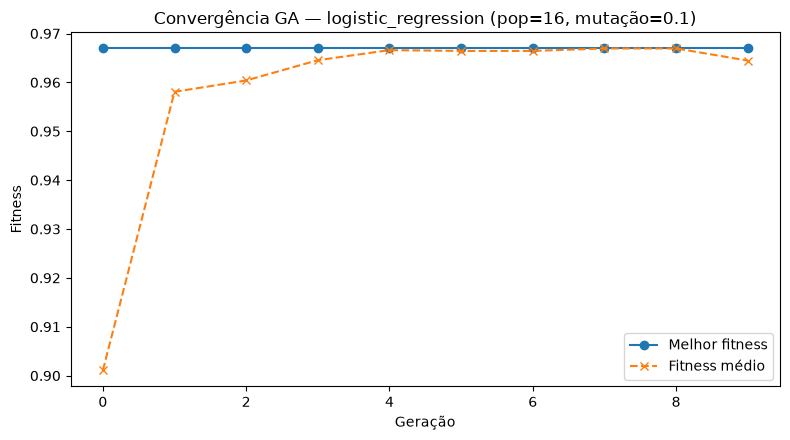

In [5]:
geracoes = [h.generation for h in resultado.history]
melhor = [h.best_fitness for h in resultado.history]
media = [h.avg_fitness for h in resultado.history]

plt.figure(figsize=(8, 4.5))
plt.plot(geracoes, melhor, marker='o', label='Melhor fitness')
plt.plot(geracoes, media, marker='x', linestyle='--', label='Fitness médio')
plt.xlabel('Geração'); plt.ylabel('Fitness')
plt.title(f'Convergência GA — {MODEL_FAMILY} (pop={POPULATION_SIZE}, mutação={MUTATION_RATE})')
plt.legend(); plt.tight_layout(); plt.show()

## 3. Comparativo: indivíduo encontrado vs. baseline original

Reajusta o melhor indivíduo no treino completo e compara com os hiperparâmetros originais do notebook da Fase 1, no mesmo conjunto de teste.

In [6]:
def original_estimator(model_family):
    if model_family == 'logistic_regression':
        return LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
    return RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE)


def metrics_on_test(pipeline, x_test, y_test):
    y_pred = pipeline.predict(x_test)
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    }


pipeline_baseline = Pipeline(steps=[
    ('preprocessor', build_preprocessor(feature_cols)),
    ('classifier', original_estimator(MODEL_FAMILY)),
]).fit(x_train, y_train)

pipeline_ga = Pipeline(steps=[
    ('preprocessor', build_preprocessor(feature_cols)),
    ('classifier', build_estimator(MODEL_FAMILY, resultado.best_individual)),
]).fit(x_train, y_train)

comparativo = pd.DataFrame([
    {'versao': 'original (Fase 1)', **metrics_on_test(pipeline_baseline, x_test, y_test)},
    {'versao': 'otimizado (GA)', **metrics_on_test(pipeline_ga, x_test, y_test)},
])
comparativo

C:\development\desafioFase2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,versao,accuracy,recall,f1
0,original (Fase 1),0.973684,0.952381,0.963855
1,otimizado (GA),0.982456,0.976190,0.976190


## 4. Integração com LLM

`gerar_explicacao` (ver `llm/explainer.py`) recebe o resultado da predição + as features do paciente e devolve uma explicação em linguagem natural. Provedor configurável via `LLM_PROVIDER=groq|openai` (env var) — se não tiver chave configurada, a célula abaixo mostra o erro tratado (`LLMUnavailableError`), do mesmo jeito que a API responde `503` nesse caso.

In [7]:
amostra_benigna = x_test.iloc[[0]]
predicao = pipeline_ga.predict(amostra_benigna)[0]
proba = pipeline_ga.predict_proba(amostra_benigna)[0]

resultado_predicao = {
    'predicao': int(predicao),
    'label': 'Maligno' if predicao == 1 else 'Benigno',
    'probabilidade_benigno': float(proba[0]),
    'probabilidade_maligno': float(proba[1]),
}
patient_features = amostra_benigna.iloc[0].to_dict()

print(resultado_predicao)

try:
    explicacao = gerar_explicacao(resultado_predicao, patient_features, pipeline_ga, feature_cols)
    print('\nExplicação da LLM:\n')
    print(explicacao)
except LLMUnavailableError as exc:
    print(f'\nLLM indisponível: {exc}')
    print('Configure GROQ_API_KEY (ou OPENAI_API_KEY + LLM_PROVIDER=openai) no ambiente pra rodar esta célula.')

{'predicao': 0, 'label': 'Benigno', 'probabilidade_benigno': 0.9990952917987229, 'probabilidade_maligno': 0.0009047082012770988}



Explicação da LLM:

O resultado do modelo de classificação indica que a amostra é provável de ser benigna, com uma probabilidade de 99,9%. Isso sugere que a lesão não é cancerígena. As características mais relevantes que contribuíram para essa predição incluem a textura média da amostra, que foi medida em 10,82, e a textura pior, que foi de 15,97.

Esses valores sugerem que a amostra apresenta uma textura relativamente uniforme, o que é consistente com lesões benignas. Além disso, o erro de textura, medido em 0,4607, também é um indicador de que a lesão não apresenta características malignas.

É importante lembrar que esse resultado é apenas uma ferramenta de apoio à decisão e não substitui a avaliação médica, mamografia, ultrassonografia nem biopsia. O profissional de saúde tem a palavra final. Ferramenta de apoio a decisao. Nao substitui avaliacao medica, mamografia, ultrassonografia nem biopsia. O profissional de saude tem a palavra final.


## 5. Conclusão

Os resultados oficiais (3 experimentos × 2 famílias de modelo, comparativo completo e avaliação da LLM em 8 casos) estão consolidados em `RELATORIO_TECNICO.md` e `reports/` — gerados por `ga/run_ga_experiments.py` e `llm/evaluation.py`. Este notebook é o mesmo código, só que interativo, célula a célula.